In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from numpy.random import default_rng

rng = default_rng()

import sys
from matplotlib.lines import Line2D

sys.path.append("../")
sys.path.append("../../")
sys.path.append("../../../")

from tcr_toolbox.epi_assembly_PRIVATE.mixmhcpred import parse_mixmhcpred_out_txt_list, run_mixmhcpred_patient_df_dict
from tcr_toolbox.epi_assembly_PRIVATE.epi_parse_utils import  align_to_add_var_start_and_end_aa_seq_ag_df
from tcr_toolbox.utils.plot_utils import simple_beeswarm2, startfig, set_mpl_params

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl, mylines = set_mpl_params(mpl=mpl)

In [ ]:
mixmhcpred_exe = "/vscode_projects/MixMHCpred/MixMHCpred"

In [ ]:
gartner_df = pd.read_csv(
    "/NmersTrainingSet.txt",
    delimiter="\t",
)
gartner_df = gartner_df.loc[gartner_df["Screening Status"].isin(["-", "CD8"]), :]
#gartner_df = gartner_df[gartner_df["ID"].map(gartner_df["ID"].value_counts()) > 75]
gartner_df.reset_index(inplace=True, drop=True)
gartner_df["AA change"] = gartner_df["AA change"].str.replace(".", "-")
gartner_df["ID"] = gartner_df["ID"].astype(str)
print(gartner_df["ID"].unique().shape[0])

print(gartner_df["Mutation type"].value_counts(), "\n")
# gartner_mut_type_rename_dict = {"stoploss": "nonframeshift insertion", "frameshift deletion": "frameshift", "frameshift insertion": "frameshift"}
# gartner_df["Mutation type"] = gartner_df["Mutation type"].replace(gartner_mut_type_rename_dict)
# print(gartner_df["Mutation type"].value_counts())

gartner_df["ag_name"] = gartner_df["ID"].astype(str) + "_" + gartner_df["Gene Name"].astype(str) + "_" + gartner_df["AA change"].astype(str)

gartner_df["dup_index"] = gartner_df.groupby("ag_name").cumcount()
dup_counts = gartner_df["ag_name"].map(gartner_df["ag_name"].value_counts())
gartner_df["ag_name"] = gartner_df["ag_name"] + "_" + gartner_df["dup_index"].astype(str)
gartner_df.drop(columns="dup_index", inplace=True)


gartner_df = align_to_add_var_start_and_end_aa_seq_ag_df(
    ag_df=gartner_df, aa_var_seq_col="Mut Epitope", aa_ref_seq_col="Wt Epitope", var_start_col="minigene_aa_var_start", var_end_col="minigene_aa_var_end"
)

70
Mutation type
nonsynonymous SNV          9240
frameshift deletion         141
frameshift insertion         85
nonframeshift deletion       70
nonframeshift insertion       6
stoploss                      1
Name: count, dtype: int64 



In [4]:
gartner_df["Screening Status"].value_counts()

Screening Status
-      9404
CD8     139
Name: count, dtype: int64

In [5]:
gartner_df["ID"].unique().shape[0]

70

In [10]:
gartner_df_dict = {}
number_minigene_list = []
number_reactive_minigene_list = []
for patient in gartner_df.loc[:, "ID"].unique():
    gartner_df_dict[patient] = gartner_df.loc[gartner_df["ID"] == patient, :].copy()
    number_minigene_list.append(gartner_df_dict[patient].shape[0])
    number_reactive_minigene_list.append(gartner_df_dict[patient]["Screening Status"].value_counts()["CD8"])
#del gartner_df
print(f"median number of minigenes/patient: {np.median(number_minigene_list)}")
print(f"median number of reactive minigenes/patient: {np.median(number_reactive_minigene_list)}")

median number of minigenes/patient: 125.0
median number of reactive minigenes/patient: 1.0


In [13]:
min(number_minigene_list)

1

In [14]:
max(number_minigene_list)

679

In [7]:
print(min(number_minigene_list))
print(max(number_minigene_list))

1
679


In [ ]:
gartner_hla_df = pd.read_excel(
    "/gartner_2021_minimal_peptide_analysis/43018_2021_197_MOESM2_ESM.xlsx",
    sheet_name=0,
    header=1,
)
gartner_hla_df = gartner_hla_df.loc[:, ["ID", "Patient HLAs"]]
gartner_hla_df = gartner_hla_df.iloc[:-1]
gartner_hla_df["ID"] = gartner_hla_df["ID"].astype(str)

In [9]:
def expand_hlas(row):
    hlas = [h.strip() for h in row["Patient HLAs"].split(",")]
    classes = {"A": [], "B": [], "C": []}

    for h in hlas:
        cls = h.split("-")[1][0]
        classes[cls].append(h)

    out = []
    for cls, alleles in classes.items():
        out.append({"ID": row["ID"], "class": f"HLA-{cls}", "allele1": alleles[0] if len(alleles) > 0 else None, "allele2": alleles[1] if len(alleles) > 1 else None})

    return pd.DataFrame(out)

In [10]:
gartner_hla_df = pd.concat(gartner_hla_df.apply(expand_hlas, axis=1).to_list(), ignore_index=True)
gartner_hla_df["allele_1_mix_enc"] = gartner_hla_df["allele1"].str.split("HLA-").str[1].str.replace(":", "")
gartner_hla_df["allele_2_mix_enc"] = gartner_hla_df["allele2"].str.split("HLA-").str[1].str.replace(":", "")

In [ ]:
gartner_dir = Path("/gartner_2021_minimal_peptide_analysis")

In [13]:
mixmhcpred_out_txt_list = run_mixmhcpred_patient_df_dict(
    patient_df_dict=gartner_df_dict,
    patient_hla_df=gartner_hla_df,
    run_dir=gartner_dir,
    kmer_list=[8, 9, 10, 11],
    gene_id_col="ag_name",
    aa_seq_col="Mut Epitope",
    hla_df_patient_col="ID",
    allele_1_col="allele_1_mix_enc",
    allele_2_col="allele_2_mix_enc",
    mixmhcpred_exe=mixmhcpred_exe,
    variant=True,
    minigene_aa_var_start_col="minigene_aa_var_start",
    minigene_aa_var_end_col="minigene_aa_var_end",
    var_type_for_kmer_overlap_col="var_type_for_kmer_overlap_col",
)

Processing: 1913
A0201,B3501,C0401,A1101,B5101,C1402
Processing: 2098
A0201,B4402,C0501
Processing: 2224
A0201,B2705,C0202,B4001,C0302
Processing: 2359
A0205,B4403,C0701,A6802,B4901,C1601
Processing: 2369
A0101,B0702,C0702,A2601,B1401,C0802
Processing: 2556
A0101,B3503,C0401,A0201,B5101,C1402
Processing: 2591
A0101,B0801,C0401,A0201,B3502,C0701
Processing: 3309
A0101,B0801,C0303,A1101,B5501,C0701
Processing: 3466
A0201,B3901,C0501,B4402,C1203
Processing: 3678
A0201,B4402,C0704,A0301,B5101,C1402
Processing: 3713
A0201,B4403,C1502,A2902,B5101,C1601
Processing: 3716
A0101,B1501,C0304,A0301,B3501,C0401
Processing: 3775
A2402,B3501,C0304,A3201,B4001,C0401
Processing: 3784
A0101,B0702,C0702,A0301
Processing: 3795
A0101,B0801,C0102,A0201,B2705,C0701
Processing: 3879
A0101,B0801,C0304,A0201,B4001,C0701
Processing: 3903
A0201,B2702,C0202,A2402,B3801,C1203
Processing: 3919
A0101,B4101,C0602,A3001,B5701,C1701
Processing: 3998
A0101,B1501,C0303,A3002,B1801,C0501
Processing: 4000
A0201,B4501,C0602,

In [14]:
keep_top_number_peptides = 500 # also run this notebook for 350 and other minimal peptide numbers

In [ ]:
parsed_csv_list = parse_mixmhcpred_out_txt_list(
    mixmhcpred_out_txt_list=mixmhcpred_out_txt_list,
    patient_df_dict=gartner_df_dict,
    gene_id_col="ag_name",
    mrna_expression_col="Gene Expression Decile for this sample(1=lowest expression-10=highest expression)",
    keep_top_number_peptides=keep_top_number_peptides,
    include_cols_patient_df_list=None,
    mrna_sorting_weight=0.2,
    percent_rank_threshold=2,
)

In [ ]:
mmp_hits_df = pd.read_excel(
    "/gartner_2021_minimal_peptide_analysis/43018_2021_197_MOESM2_ESM.xlsx",
    sheet_name=2,
    header=1,
)
mmp_hits_df = mmp_hits_df.iloc[:-1]
mmp_hits_df["ID"] = mmp_hits_df["ID"].astype(str).str[:-2]
mmp_hits_df["HLA_proc"] = mmp_hits_df["HLA"].str.split("-").str[1].str.replace(":", "")
mmp_hits_df["intersect_col"] = mmp_hits_df["Mutant minimal Peptide"] + "_" + mmp_hits_df["HLA_proc"]

In [17]:
gartner_hit_df = gartner_df.loc[gartner_df["Screening Status"] == "CD8", :]

In [18]:
mmp_hits_df

,ID,Gene Name,Wild type nmer,Mutant nmer,Wild type minimal peptied,Mutant minimal Peptide,mmp Length,HLA,Mutation present in RNA-seq,Gene expression decile,...,NetMHCpan4.0 BA Model Wild Type Rank,HLAthena Mutant Rank,HLAthena Wild Type Rank,MixMHCpred2.0.2 Mutant Rank,MixMHCpred2.0.2 Wild Type Rank,MHCflurry1.6 Mutant Rank,MHCflurry1.6 Wild Type Rank,MHCflurry1.6 WT:Mut Rank,HLA_proc,intersect_col
0,1913,CDKN2A,RRPGHDDGQRPSGGAAAAPRRGAQL,RRPGHDDGQRPSGSCCCSTARSPTAPTPPLSPDPCTTLPGRASWTR...,-,AVCPWTWLR,9.0,HLA-A11:01,1.0,10.0,...,-,0.0724,-,0.04,-,0.033625,-,-,A1101,AVCPWTWLR_A1101
1,2098,CSNK1A1,GKYKLVRKIGSGSFGDIYLAINITN,GKYKLVRKIGSGLFGDIYLAINITN,GSFGDIYLA,GLFGDIYLA,9.0,HLA-A02:01,1.0,10.0,...,3.0844,0.4094,12.310999,0.3,10,0.070500,0.8535,12.106383,A0201,GLFGDIYLA_A0201
2,2098,HAUS3,LKQSQGILNAMITKISNELQALTDE,LKQSQGILNAMIAKISNELQALTDE,ILNAMITKI,ILNAMIAKI,9.0,HLA-A02:01,1.0,7.0,...,0.5848,0.9524,0.85952,0.4,0.4,0.215375,0.159375,0.739988,A0201,ILNAMIAKI_A0201
3,2098,GAS7,QVKKSLADEAEVHLKFSAKLHSEVE,QVKKSLADEAEVYLKFSAKLHSEVE,SLADEAEVHL,SLADEAEVYL,10.0,HLA-A02:01,1.0,10.0,...,0.9606,0.0762,0.168046,0.07,0.2,0.177000,0.263125,1.486582,A0201,SLADEAEVYL_A0201
4,2098,GAPDH,VIHDNFGIVEGLMTTVHAITATQKT,VIHDNFGIVEGLITTVHAITATQKT,GIVEGLMTTV,GIVEGLITTV,10.0,HLA-A02:01,0.0,10.0,...,0.6131,0.2134,0.49919,0.4,0.6,0.185875,0.2215,1.191661,A0201,GIVEGLITTV_A0201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,4326,ISLR,MDSNELTFIPRDAFRSLRALRSLQL,MDSNELTFIPRDVFRSLRALRSLQL,IPRDAFRSL,IPRDVFRSL,9.0,HLA-B07:02,1.0,9.0,...,0.0092,0.0213,0.0279,0.01,0.01,0.012250,0.00875,0.714286,B0702,IPRDVFRSL_B0702
116,4329,TRIO,AHQLEDRIQDFVRRVEQRKILLDMS,AHQLEDRIQDFVQRVEQRKILLDMS,RIQDFVRRV,RIQDFVQRV,9.0,HLA-A02:01,1.0,10.0,...,3.3094,0.4809,0.939402,0.02,0.04,0.064125,0.263125,4.103314,A0201,RIQDFVQRV_A0201
117,4335,RSL1D1,SGSCSAIRIGHVGMQIEHIIENIVA,SGSCSAIRIGHVRMQIEHIIENIVA,IRIGHVGMQI,IRIGHVRMQI,10.0,HLA-B08:01,1.0,10.0,...,17.0799,12.1584,14.934145,50,30,10.417125,10.0565,0.965382,B0801,IRIGHVRMQI_B0801
118,4345,GNPTG,EQTFRWNAYSGILGIWHEWEIANNT,EQTFRWNAYSGIRGIWHEWEIANNT,YSGILGIWHEW,YSGIRGIWHEW,11.0,HLA-B57:01,1.0,10.0,...,0.1775,1.4787,0.785894,0.7,0.5,0.214250,0.166625,0.777713,B5701,YSGIRGIWHEW_B5701


In [19]:
hit_merge_df = pd.merge(gartner_hit_df, mmp_hits_df, left_on = "Mut Epitope", right_on = "Mutant nmer", how = "left")

In [20]:
gartner_hit_df

,Variant key,"seen in RNA (1=Yes,0=No)",ID,tumor type,1000genome all freq,dbSNP_ID,Cosmic Info,CGC Tier,Gene Name,All Transcripts AAchange for 25mer,...,Mut Epitope,Gene Expression Decile for this sample(1=lowest expression-10=highest expression),Exome VAF Decile,Screening Status,Comments,key,ag_name,minigene_aa_var_start,minigene_aa_var_end,var_type_for_kmer_overlap_col
0,"9:21971178-21971179 CG>-, 9:21971181-21971181 C>A",1.0,1913,MELANOMA,-,-,-,1,CDKN2A,"ENST00000530628,p.G74fs|NM_058195,p.G74fs|ENST...",...,RRPGHDDGQRPSGSCCCSTARSPTAPTPPLSPDPCTTLPGRASWTR...,10.0,9.0,CD8,"fs,snv,coded into 3'UTR PR","1913_9:21971178-21971179 CG>-, 9:21971181-2197...",1913_CDKN2A_p-G74fs_0,13,77,missense_or_inframe_ins_or_frameshift
1,5:148930448-148930448 G>A,1.0,2098,MELANOMA,-,-,-,-,CSNK1A1,"uc003lqx.2,p.S27F|NM_001892,p.S27F|ENST0000051...",...,GKYKLVRKIGSGLFGDIYLAINITN,10.0,9.0,CD8,"dnv, p.S27F>p.S27L PR",2098_5:148930448-148930448 G>A_GKYKLVRKIGSGLFG...,2098_CSNK1A1_p-S27F_0,12,13,missense_or_inframe_ins_or_frameshift
2,17:9837503-9837503 G>A,1.0,2098,MELANOMA,-,-,-,1,GAS7,"uc002gmh.1,p.H149Y|uc010vvd.1,p.H241Y|NM_20143...",...,QVKKSLADEAEVYLKFSAKLHSEVE,10.0,4.0,CD8,-,2098_17:9837503-9837503 G>A_QVKKSLADEAEVYLKFSA...,2098_GAS7_p-H241Y_0,12,13,missense_or_inframe_ins_or_frameshift
3,4:2242196-2242196 T>C,1.0,2098,MELANOMA,-,-,-,-,HAUS3,"ENST00000443786,p.T160A|uc003ges.1,p.T160A|uc0...",...,LKQSQGILNAMIAKISNELQALTDE,7.0,7.0,CD8,-,2098_4:2242196-2242196 T>C_LKQSQGILNAMIAKISNEL...,2098_HAUS3_p-T160A_0,12,13,missense_or_inframe_ins_or_frameshift
4,12:6646556-6646556 G>A,0.0,2098,MELANOMA,-,-,-,-,GAPDH,"ENST00000396856,p.M100I|ENST00000396859,p.M175...",...,VIHDNFGIVEGLITTVHAITATQKT,10.0,1.0,CD8,-,2098_12:6646556-6646556 G>A_VIHDNFGIVEGLITTVHA...,2098_GAPDH_p-M133I_0,12,13,missense_or_inframe_ins_or_frameshift
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8869,5:14336772-14336772 G>A,1.0,4329,COLON,-,-,-,-,TRIO,"uc003jfh.1,p.R310Q|uc011cna.1,p.R612Q|ENST0000...",...,AHQLEDRIQDFVQRVEQRKILLDMS,10.0,10.0,CD8,-,4329_5:14336772-14336772 G>A_AHQLEDRIQDFVQRVEQ...,4329_TRIO_p-R612Q_0,12,13,missense_or_inframe_ins_or_frameshift
8950,16:11935835-11935835 C>T,1.0,4335,COLON,-,-,-,-,RSL1D1,"uc010buv.1,p.G220R|uc002dbp.1,p.G220R|NM_01565...",...,SGSCSAIRIGHVRMQIEHIIENIVA,10.0,7.0,CD8,-,4335_16:11935835-11935835 C>T_SGSCSAIRIGHVRMQI...,4335_RSL1D1_p-G220R_0,12,13,missense_or_inframe_ins_or_frameshift
9207,16:1411953-1411953 T>G,1.0,4345,COLON,-,-,-,-,GNPTG,"NM_032520,p.L105R|ENST00000204679,p.L105R|uc00...",...,EQTFRWNAYSGIRGIWHEWEIANNT,10.0,7.0,CD8,-,4345_16:1411953-1411953 T>G_EQTFRWNAYSGIRGIWHE...,4345_GNPTG_p-L105R_0,12,13,missense_or_inframe_ins_or_frameshift
9410,3:53856534-53856534 T>C,1.0,4346,COLORECTAL,-,-,-,-,CHDH,"NM_018397,p.N280S|ENST00000315251,p.N280S|uc00...",...,EGTRAVGVEYVKSGQSHRAYASKEV,6.0,8.0,CD8,-,4346_3:53856534-53856534 T>C_EGTRAVGVEYVKSGQSH...,4346_CHDH_p-N280S_0,12,13,missense_or_inframe_ins_or_frameshift


In [21]:
len(set(gartner_hit_df["Mut Epitope"]).difference(set(mmp_hits_df["Mutant nmer"])))

23

In [22]:
hit_merge_df["Mutant minimal Peptide"].isna().sum()

np.int64(23)

In [23]:
gartner_hit_df.shape

(139, 27)

In [24]:
mmp_hits_df.groupby("ID")["Mutant minimal Peptide"].nunique().max()

11

In [25]:
mmp_hits_df.groupby("ID")["Mutant minimal Peptide"].nunique().median()

1.0

In [26]:
frac_recover_dict = {}
total_hits = 0
hits_per_patient_list = []
parsed_df_dict = dict()
for parsed_csv in parsed_csv_list:
    patient = parsed_csv.stem.split("_")[0]
    print(patient)
    print(gartner_df_dict[patient].shape[0])
    tmp_gartner_hla_df = gartner_hla_df.loc[gartner_hla_df["ID"] == patient, :]
    hla_list = (
        tmp_gartner_hla_df.loc[tmp_gartner_hla_df["ID"] == patient, "allele_1_mix_enc"].dropna().tolist()
        + tmp_gartner_hla_df.loc[tmp_gartner_hla_df["ID"] == patient, "allele_2_mix_enc"].dropna().tolist()
    )
    hla_str = ",".join(hla_list)
    # print(hla_str)
    patient_mmp_hits_df = mmp_hits_df.loc[mmp_hits_df["ID"] == patient, :].copy()
    if patient_mmp_hits_df.shape[0] == 0:
        print("No hits")
        continue
    print(patient_mmp_hits_df.shape[0])
    total_hits += patient_mmp_hits_df.shape[0]
    hits_per_patient_list.append(patient_mmp_hits_df.shape[0])
    parsed_df_dict[patient] = pd.read_csv(parsed_csv, index_col=0)
    parsed_df_dict[patient]["intersect_col"] = parsed_df_dict[patient]["Peptide"] + "_" + parsed_df_dict[patient]["BestAllele"]

    num_intersect = len(set(patient_mmp_hits_df["intersect_col"]).intersection(set(parsed_df_dict[patient]["intersect_col"])))
    print(set(patient_mmp_hits_df["intersect_col"]).intersection(set(parsed_df_dict[patient]["intersect_col"])))
    frac_intersect_hits = num_intersect / len(set(patient_mmp_hits_df["intersect_col"]))

    frac_recover_dict[patient] = frac_intersect_hits
    print(num_intersect)
    print(frac_intersect_hits)


1913
1
1
{'AVCPWTWLR_A1101'}
1
1.0
2098
4
4
{'GLFGDIYLA_A0201', 'GIVEGLITTV_A0201', 'SLADEAEVYL_A0201', 'ILNAMIAKI_A0201'}
4
1.0
2224
1
1
{'VIDANIFSV_A0201'}
1
1.0
2359
53
1
{'RLFPGLTIKI_A0205'}
1
1.0
2369
165
3
{'LTDDRLFTCY_A0101', 'FPPDKMLLF_A2601', 'YTDFHCQYV_A0101'}
3
1.0
2556
175
2
{'QVDFSVLHY_A0101'}
1
0.5
2591
187
1
set()
0
0.0
3309
2
2
{'KTLTSVFQK_A1101', 'CILGKLFTK_A1101'}
2
1.0
3466
398
6
{'LLGVKLFGV_A0201', 'HRCTLQPSL_B3901', 'YQQPPGPVL_B3901', 'ALIHHNTYL_A0201', 'EEHNHIQQW_B4402'}
5
0.8333333333333334
3678
118
5
{'EEDGAGGHSL_B4402', 'LIRETQPITK_A0301', 'SYMIMEIEL_C1402', 'GLLDEDFYA_A0201'}
4
0.8
3713
679
11
{'QTNPVTLQY_A2902', 'TEDEHFEFY_B4403', 'TLYSLTLLY_A2902', 'FLIYLDVSV_A0201', 'AEHSLQVAY_B4403', 'EVLPFFLFF_A2902', 'TLWCSPIKV_A0201', 'FMPDFDLHL_A0201'}
8
0.7272727272727273
3716
48
2
{'GQFLTPNSH_B1501'}
1
0.5
3775
210
3
{'VESEDIAEL_B4001', 'IPIDGIFFTY_B3501', 'RTKVVQTLW_A3201'}
3
1.0
3784
123
3
{'RVSTLRVSL_B0702', 'RARSRTPSC_B0702'}
2
0.6666666666666666
3795
144
2
{'ILD

In [27]:
print(np.quantile(list(frac_recover_dict.values()), 0.25))
print(np.mean(list(frac_recover_dict.values())))

1.0
0.8515399900645801


In [28]:
log_txt = gartner_dir / "mixmhcpred" / "outs" / "parse_mixmhcpred_out_txt.log"
predicted_num_peptides_list = []
with open(log_txt, "r") as txt_in:
    for line in txt_in:
        if line.startswith("Number of predicted peptides"):
            predicted_num_peptides_list.append(int(line.split(": ")[1]))

median_predicted_num_peptides = np.median(predicted_num_peptides_list)
min_predicted_num_peptides = np.min(predicted_num_peptides_list)
max_predicted_num_peptides = np.max(predicted_num_peptides_list)

In [28]:
frac_recover_dict = {}
total_hits = 0
hits_per_patient_list = []
parsed_df_dict = dict()
for parsed_csv in parsed_csv_list:
    patient = parsed_csv.stem.split("_")[0]
    print(patient)
    print(gartner_df_dict[patient].shape[0])
    tmp_gartner_hla_df = gartner_hla_df.loc[gartner_hla_df["ID"] == patient, :]
    hla_list = (
        tmp_gartner_hla_df.loc[tmp_gartner_hla_df["ID"] == patient, "allele_1_mix_enc"].dropna().tolist()
        + tmp_gartner_hla_df.loc[tmp_gartner_hla_df["ID"] == patient, "allele_2_mix_enc"].dropna().tolist()
    )
    hla_str = ",".join(hla_list)
    # print(hla_str)
    patient_mmp_hits_df = mmp_hits_df.loc[mmp_hits_df["ID"] == patient, :].copy()
    if patient_mmp_hits_df.shape[0] == 0:
        print("No hits")
        continue
    print(patient_mmp_hits_df.shape[0])
    print(len(set(patient_mmp_hits_df["Mutant minimal Peptide"])))
    total_hits += patient_mmp_hits_df.shape[0]
    hits_per_patient_list.append(patient_mmp_hits_df.shape[0])
    parsed_df_dict[patient] = pd.read_csv(parsed_csv, index_col=0)
    parsed_df_dict[patient]["intersect_col"] = parsed_df_dict[patient]["Peptide"] + "_" + parsed_df_dict[patient]["BestAllele"]

    num_intersect = len(set(patient_mmp_hits_df["Mutant minimal Peptide"]).intersection(set(parsed_df_dict[patient]["Peptide"])))
    print(set(patient_mmp_hits_df["Mutant minimal Peptide"]).intersection(set(parsed_df_dict[patient]["Peptide"])))
    print(set(patient_mmp_hits_df["intersect_col"]).intersection(set(parsed_df_dict[patient]["intersect_col"])))

    print(set(patient_mmp_hits_df["intersect_col"]).difference(set(parsed_df_dict[patient]["intersect_col"])))
    frac_intersect_hits = num_intersect / len(set(patient_mmp_hits_df["Mutant minimal Peptide"]))

    frac_recover_dict[patient] = frac_intersect_hits
    print(num_intersect)
    print(frac_intersect_hits)
    print("\n")


2369
165
3
3
{'YTDFHCQYV', 'LTDDRLFTCY', 'FPPDKMLLF'}
{'LTDDRLFTCY_A0101', 'YTDFHCQYV_A0101', 'FPPDKMLLF_A2601'}
set()
3
1.0


2556
175
2
2
{'FSGEYIPTV', 'QVDFSVLHY'}
{'QVDFSVLHY_A0101'}
{'FSGEYIPTV_A0201'}
2
1.0


2591
187
1
1
set()
set()
{'TRSSGSHFV_C0701'}
0
0.0


3466
398
6
6
{'ALIHHNTYL', 'LLGVKLFGV', 'HRCTLQPSL', 'EEHNHIQQW', 'YQQPPGPVL', 'VLENFTIFL'}
{'EEHNHIQQW_B4402', 'ALIHHNTYL_A0201', 'LLGVKLFGV_A0201', 'YQQPPGPVL_B3901', 'HRCTLQPSL_B3901'}
{'VLENFTIFL_A0201'}
6
1.0


3678
118
5
5
{'SYMIMEIEL', 'GLLDEDFYA', 'EEDGAGGHSL', 'LIRETQPITK'}
{'SYMIMEIEL_C1402', 'EEDGAGGHSL_B4402', 'GLLDEDFYA_A0201', 'LIRETQPITK_A0301'}
{'APLCRNHI_B5101'}
4
0.8


3713
679
11
11
{'FFYLLDFTF', 'FLIYLDVSV', 'FMPDFDLHL', 'TLWCSPIKV', 'AEHSLQVAY', 'EVLPFFLFF', 'TEDEHFEFY', 'QTNPVTLQY', 'TLYSLTLLY'}
{'TLYSLTLLY_A2902', 'EVLPFFLFF_A2902', 'TLWCSPIKV_A0201', 'QTNPVTLQY_A2902', 'FMPDFDLHL_A0201', 'TEDEHFEFY_B4403', 'AEHSLQVAY_B4403', 'FLIYLDVSV_A0201'}
{'FFYLLDFTF_A2902', 'RVCGPCSTY_A2902', 'IMQTLAGELY_A2902

In [29]:
print(np.quantile(list(frac_recover_dict.values()), 0.25))
print(np.mean(list(frac_recover_dict.values())))

1.0
0.9139764996907853


0.8515399900645801


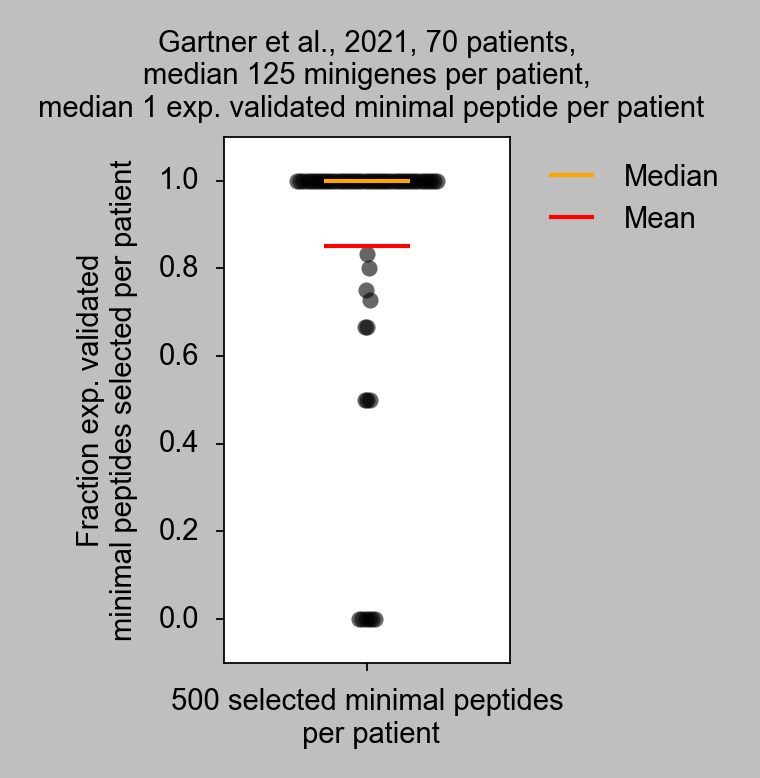

In [ ]:
ax, fig, gs = startfig(6.5, 7)

y = list(frac_recover_dict.values())
print(np.mean(y))
x_swarm = simple_beeswarm2(y, width=0.25)
ax.scatter(x_swarm + 1, y, s=15, color="black", alpha=0.6, linewidths=0, zorder=-4)

ax.boxplot(
    y,
    positions=[1],
    widths=0.3,
    patch_artist=True,
    showfliers=False,
    showmeans=True,
    meanline=True, 
    boxprops=dict(facecolor="none", color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="orange", linewidth=1),
    meanprops=dict(color="red", linewidth=1, linestyle="-"),
    flierprops=dict(marker="o", color="black", alpha=0.5, markersize=4),
)

ax.set_ylabel("Fraction exp. validated\nminimal peptides selected per patient", fontsize=7)
ax.set_xticklabels([f"{keep_top_number_peptides} selected minimal peptides\n per patient"], fontsize=7)
ax.tick_params("both", labelsize=7)
ax.set_title(
    f"Gartner et al., 2021, 70 patients,\nmedian 125 minigenes per patient,\n median 1 exp. validated minimal peptide per patient",
    fontsize=7,
)
ax.set_xlim(0.5, 1.5)
ax.set_ylim(-0.1, 1.1)

legend_handles = [
    Line2D([0], [0], color="orange", lw=1, label="Median"),
    Line2D([0], [0], color="red", lw=1, label="Mean"),
]

ax.legend(
    handles=legend_handles,
    fontsize=7,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)
ax.tick_params(top = False, right = False)

fig.tight_layout()
fig.savefig(
    f"/gartner_2021_minimal_peptide_analysis/outs/boxplot_minimal_peptides_wo_hla_alllele_recovered_{keep_top_number_peptides}_for_publication.pdf"
)